In [105]:
import sys
sys.path.insert(0, '../../')

import time
import numpy as np
from typing import Tuple
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from deepssfp import ssfp, recon

def get_t1_t2(num_samples=100, mode='uniform') -> Tuple[np.ndarray, np.ndarray]:
    if mode == 'uniform':
        T1 = np.random.uniform(0.5, 2.0, num_samples)
        T2 = np.random.uniform(0.01, 0.1, num_samples)
    elif mode == 'ratio':
        ratio_min = 0.5
        ratio_max = 20
        t2_min = 0.05
        t2_max = 0.1
        ratios = np.random.uniform(ratio_min, ratio_max, num_samples)
        T2 = np.random.uniform(t2_min, t2_max, num_samples)
        T1 = T2 * ratios
    elif mode == 'tissue':
        tissues = {
            #'none': [0, 0],
            'water': [4, 2],
            'white-matter': [0.6, 0.08],
            'gray-matter': [0.9, 0.1],
            'muscle': [0.9, .05],
            'fat': [0.25, 0.07], 
            'liver': [0.5, 0.04],
            #'tendon': [0.4, 0.005],
            #'proteins': [0.250, 0.001]
        }

        indices = np.random.choice(len(tissues), num_samples, replace=True)
        keys = [list(tissues.keys())[i] for i in indices]
        T1 = [tissues[key][0] for key in keys]
        T2 = [tissues[key][1] for key in keys]
    else:
        assert False, 'Invalid mode'

    return T1, T2 # type: ignore

def generate_training_data_pts(num_samples=100, num_pcs=4, t1t2_mode='uniform'):
    T1, T2 = get_t1_t2(num_samples, mode=t1t2_mode)
    TR = 5e-3
    alpha = np.deg2rad(30)
    TE = TR / 2.0
    BetaMax = 2 * np.pi
    beta = np.random.uniform(-BetaMax, BetaMax, num_samples)
    f = beta / TR / (2 * np.pi)
    pcs = np.linspace(0, 2 * np.pi, num_pcs, endpoint=True)
    
    X = []
    y = []

    for i in range(num_samples):
        M_2pc = ssfp.ssfp(T1[i], T2[i], TR, TE, alpha, pcs, f0=f[i])
        X.append(M_2pc)
        
        M_4pc = ssfp.ssfp(T1[i], T2[i], TR, TE, alpha, np.linspace(0, 2*np.pi, 4, endpoint=False), f0=f[i])
        y.append(np.sqrt(np.mean(np.abs(M_4pc)**2)))
    
    return np.array(X), np.array(y)

def generate_training_data_1d(num_samples=100, num_pcs=4, N = 128, t1t2_mode='uniform'):
    T1, T2 = get_t1_t2(num_samples, mode=t1t2_mode)
    TR = 5e-3
    alpha = np.deg2rad(30)
    TE = TR / 2.0
    BetaMax = 2 * np.pi
    beta = np.linspace(-BetaMax, BetaMax, N)
    f = beta / TR / (2 * np.pi)
    pcs = np.linspace(0, 2 * np.pi, num_pcs, endpoint=True)
    
    X = []
    y = []
    
    for i in range(num_samples):
        M_2pc = ssfp.ssfp(T1[i], T2[i], TR, TE, alpha, pcs, f0=f)
        X.append(M_2pc)
        
        M_4pc = ssfp.ssfp(T1[i], T2[i], TR, TE, alpha, np.linspace(0, 2*np.pi, 4, endpoint=False), f0=f)
        y.append(np.sqrt(np.mean(np.abs(M_4pc)**2, axis=1)))
    
    return np.array(X), np.array(y)

def generate_training_data_2d(num_samples=100, npcs=4, N = 128, t1t2_mode='uniform'):
    T1, T2 = get_t1_t2(num_samples, mode=t1t2_mode)
    T1 = np.tile(T1, (N, N, 1))
    T2 = np.tile(T2, (N, N, 1))
    TR, alpha = 5e-3, np.deg2rad(30)
    TE = TR / 2.0
    BetaMax = 2 * np.pi
    beta = np.linspace(-BetaMax, BetaMax, N)
    f = beta / TR / (2 * np.pi)
    f = np.tile(f, (N, 1))
    pcs = np.linspace(0, 2*np.pi, npcs, endpoint=False)

    X = np.zeros((num_samples, N, N, 4), dtype=np.complex128)
    Y = np.zeros((num_samples, N, N, 4), dtype=np.complex128)
    for i in range(num_samples):
        X[i, :, :, :] = ssfp.ssfp(T1[:,:,i], T2[:,:,i], TR, TE, alpha, pcs, field_map=f)
        Y[i, :, :, :] = ssfp.ssfp(T1[:,:,i], T2[:,:,i], TR, TE, alpha, np.linspace(0, 2*np.pi, 4, endpoint=False), field_map=f)
    Y = np.sqrt(np.mean(np.abs(Y)**2, axis=3))
    
    return X, Y


In [106]:
get_t1_t2(10, mode='tissue')

([0.25, 0.25, 0.25, 0.25, 4, 0.6, 4, 0.6, 0.5, 0.9],
 [0.07, 0.07, 0.07, 0.07, 2, 0.08, 2, 0.08, 0.04, 0.05])

(100, 4)


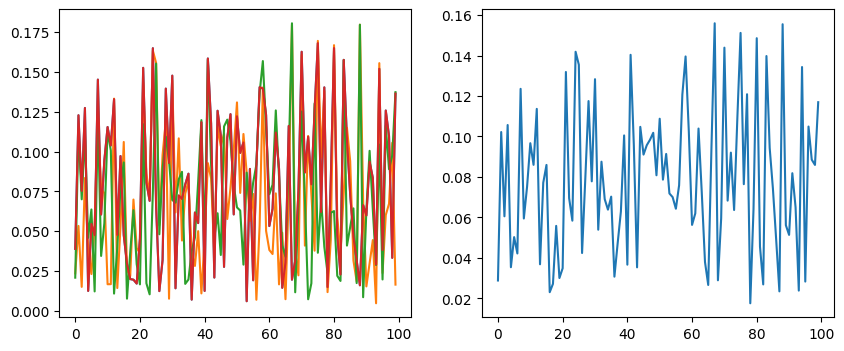

In [118]:
x, y = generate_training_data_pts()
print(x.shape)

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].plot(np.abs(x))
axs[1].plot(np.abs(y))
plt.show()

(100, 128, 4) (100, 128)


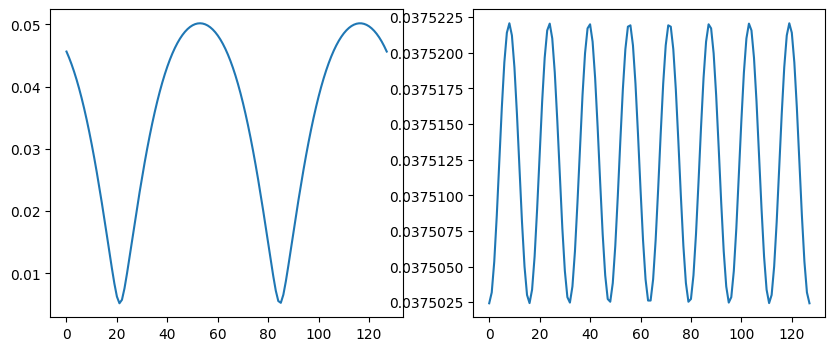

In [116]:
x, y = generate_training_data_1d()
print(x.shape, y.shape)

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].plot(np.abs(x[0,:,1]))
axs[1].plot(np.abs(y[0]))
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

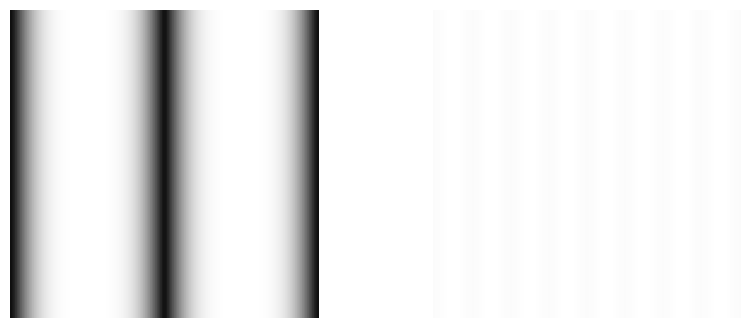

In [117]:
x, y = generate_training_data_2d()

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
index = 0
axs[0].imshow(np.abs(x[index, :, :, 0]), cmap='gray', vmin=0)
axs[0].axis('off')
axs[1].imshow(np.abs(y[index, :, :]), cmap='gray', vmin=0)
axs[1].axis('off')
plt.show